In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score

In [117]:
test, train = pd.read_csv("test.csv"), pd.read_csv("train.csv")
train.head()

,row ID,x,y
0,0,8.446388,2
1,1,5.472369,1
2,2,5.477175,1
3,3,3.253145,0
4,4,11.459214,2


In [118]:
train['y'].value_counts()

y
2    355
0    326
1    319
Name: count, dtype: int64

В даних у нас є лише одна ознака - $x$, треба передбачити $y$, який набуває тільки три значення, розподіл збалансований

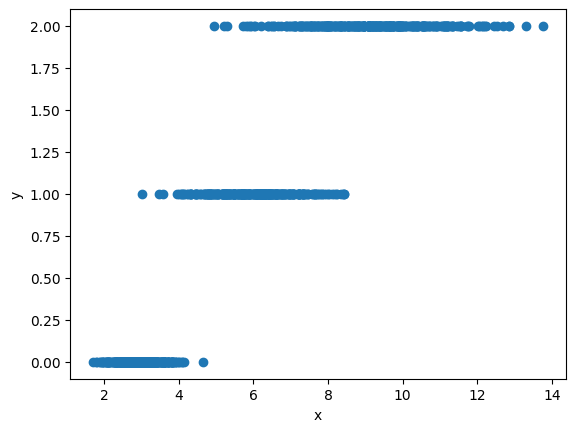

In [119]:
plt.scatter(train['x'], train['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Побудувати графік я додумалась не одразу, а треба було б, бо бачимо чітку сегментацію, хоч і не ідеальну. Межі між класами не є строго вертикальними, що може означати нелінійну розділювальну поверхню або наявність шуму і викидів. Проте все одно маємо три домінуючі зони, можна просто три іфчика написати і вже набрати купу балів, але через те що я цю тенденцію не побачила відразу, я одразу почала перевіряти базові методи класифікації.

In [120]:
x = train[['x']]
y = train['y']

x_train, x_test, y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [84]:
bayes = GaussianNB()
bayes.fit(x_train, y_train)
y_bayes = bayes.predict(x_test)

print("naive bayes:", accuracy_score(y_test, y_bayes))

naive bayes: 0.89


In [85]:
for k in range(2, 6):
    knn = KNeighborsClassifier(k)
    knn.fit(x_train, y_train)
    y_knn = knn.predict(x_test)
    print("knn k =", k, accuracy_score(y_test, y_knn))

knn k = 2 0.865
knn k = 3 0.885
knn k = 4 0.875
knn k = 5 0.885


In [86]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_lr = lr.predict(x_test)

print("logistic regression:", accuracy_score(y_test, y_lr))

logistic regression: 0.885


In [87]:
svm = SVC()
params = {
    'kernel': ('linear', 'rbf', 'sigmoid'),
    'C': [0.1, 1, 5],
    'gamma': ['scale', 0.1, 1]}

svm_select = GridSearchCV(svm, params, refit=True, cv=3)
svm_select.fit(x_train, y_train)

print("best params:", svm_select.best_params_)

best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [88]:
svm = SVC(C=0.1, kernel='linear')
svm.fit(x_train, y_train)
y_svm = svm.predict(x_test)

print("svm:", accuracy_score(y_test, y_svm))

svm: 0.88


In [89]:
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(x_train, y_train)
y_tree = tree.predict(x_test)

print("decision tree:", accuracy_score(y_test, y_tree))

decision tree: 0.87


In [121]:
sorted_train = train.sort_values('x')
sorted_train[340:400]

,row ID,x,y
542,542,4.317184,1
538,538,4.332060,1
633,633,4.428878,1
20,20,4.438530,1
561,561,4.457758,1
726,726,4.460045,1
585,585,4.475047,1
489,489,4.478259,1
744,744,4.559265,1
477,477,4.566395,1


От тільки зараз я вирішила побудувати графік, бо бачим аж надто підозрілий розподіл значень. Сортуємо $x$, для кожної сусідньої пари рядків, де значення $y$ змінювалося, обчислюємо середнє арифметичне як потенційну межу між класами, щоб краще зрозуміти дані.

In [122]:
thresholds = []
for i in range(len(sorted_train) - 1):
    if sorted_train.iloc[i]['y'] != sorted_train.iloc[i+1]['y']:
        thresholds.append((sorted_train.iloc[i]['x'] + sorted_train.iloc[i+1]['x']) / 2)

thresholds

[np.float64(3.001484643939616),
 np.float64(3.0051011297341095),
 np.float64(3.4618218397334104),
 np.float64(3.4771388360412354),
 np.float64(3.5739839093654715),
 np.float64(3.583623412648728),
 np.float64(3.925748872516837),
 np.float64(3.9445912752353074),
 np.float64(4.016583990522886),
 np.float64(4.068955726515984),
 np.float64(4.087246352301509),
 np.float64(4.12889852832133),
 np.float64(4.1347352718945025),
 np.float64(4.644431319179336),
 np.float64(4.659936024918335),
 np.float64(4.941053255400451),
 np.float64(4.961296805087343),
 np.float64(5.220510305299926),
 np.float64(5.224996578745946),
 np.float64(5.288867606603633),
 np.float64(5.297695171994217),
 np.float64(5.710601882447121),
 np.float64(5.714815349220006),
 np.float64(5.80647273844484),
 np.float64(5.810758328517334),
 np.float64(5.8384390553587),
 np.float64(5.848338774975847),
 np.float64(5.8931780558069775),
 np.float64(5.907441471733154),
 np.float64(5.918342419039547),
 np.float64(5.928887977249662),
 np.f

In [123]:
best_acc = 0
best_t1, best_t2 = None, None

for i in range(len(thresholds)):
    for j in range(i+1, len(thresholds)):
        t1, t2 = thresholds[i], thresholds[j]
        preds = np.where(x_train['x'] < t1, 0, np.where(x_train['x'] <t2, 1, 2))
        acc = accuracy_score(y_train, preds)
        if acc > best_acc:
            best_acc, best_t1, best_t2 = acc, t1, t2

print(best_acc, best_t1, best_t2)

0.93125 4.016583990522886 7.380737202776695


Проходимося по всіх трешхолдах і визначаємо два найкращі (при яких отримуємо найвищу точність) - це і є межі розділу на класи. Використовуючи обрані трешхолди пишемо простеньку модель класифікації, в результаті якої отримуємо найліпшу точність з усіх попередніх методів. Заповнуємо датафрейм з передбченими значеннями

In [124]:
def predict_thr(x, t1=best_t1, t2=best_t2):
    if x < t1:
        return 0
    elif x < t2:
        return 1
    else:
        return 2

In [125]:
simple_pred = x_test["x"].apply(predict_thr)
print("test prediction:", accuracy_score(y_test, simple_pred))

test prediction: 0.895


In [126]:
res_pred = test["x"].apply(predict_thr)
submission = pd.DataFrame({
    'row ID': test['row ID'],
    'y': res_pred
})
submission.to_csv("submission.csv", index=False)

In [127]:
submission.head()

,row ID,y
0,1000,2
1,1001,2
2,1002,1
3,1003,2
4,1004,1


Оскільки між класами немає точної вертикальної лінії, спробуємо додати поліноміальні ознаки для перевірки криволінійних меж. Також візьмемо додаткові ознаки - відстані до трешхолдів і з якого боку від них знаходиться значення. 

In [106]:
poly = PolynomialFeatures(degree=3, include_bias=False)
x_poly = poly.fit_transform(train[['x']].values)

In [108]:
train['dist_t1'] = abs(train['x'] - best_t1)
train['dist_t2'] = abs(train['x'] - best_t2)
train['side'] = [0 if i < best_t1 else (1 if i < best_t2 else 2) for i in train['x']]

x_new = np.column_stack([
    train['x'].values,
    x_poly,
    train['dist_t1'].values,
    train['dist_t2'].values,
train['side'].values
])

Тренуємо дві моделі на однакових наборах ознак, порівнюємо їхні передбачення, якщо однакові результуючі класи - повертаєм цей клас, інкаше - використовуємо попередній підхід.

In [113]:
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
rf.fit(x_new, y_new)
gb.fit(x_new, y_new)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [115]:
def predict_mix(x):
    x_poly = poly.transform(np.array([[x]]))
    dist_t1 = abs(x - best_t1)
    dist_t2 = abs(x - best_t2)
    side = 0 if x < best_t1 else (1 if x < best_t2 else 2)

    x_point = np.array([[x, *x_poly[0], dist_t1, dist_t2, side]])

    p1 = rf.predict(x_point)[0]
    p2 = gb.predict(x_point)[0]

    if p1 == p2:
        return p1
    else:
        return 0 if x < best_t1 else (1 if x < best_t2 else 2)

In [116]:
test_preds = x_test['x'].apply(predict_mix)
print("accuracy:", accuracy_score(y_test, test_preds))

accuracy: 0.955


In [112]:
res_pred = test["x"].apply(predict_mix)
submission = pd.DataFrame({
    'row ID': test['row ID'],
    'y': res_pred
})
submission.to_csv("submission.csv", index=False)

In [59]:
submission.head()

,row ID,y
0,1000,2
1,1001,2
2,1002,1
3,1003,2
4,1004,1


Вдалось покращити точність на тренувальних даних, це все звісно супер, але по факту отримали перенавчання, бо модель завчила дані і підлаштувалась під них. + всі ці нові ознаки, які додалися, не дають нової інформації, а виходить забагато ознак для 1000 точок. Тож зупиняємося на попередньому варіанті, він є найоптимальнішим з усіх описаних. 

Отож підсумовуючи, варто від початку враховувати, що ми маємо лише одну ознаку, три класи, нелінійну залежність із перекриттями, а також обмежену кількість тренувальних даних (1000 точок), вибір методу класифікації має ґрунтуватися на принципі простоти. Метод із трешхолдами даватиме стабільно високу точність і є оптимальним компромісом між точністю передбачень та узагальнювальною здатністю.